In [1]:
import pandas as pd
import numpy as np
import joblib
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score,roc_auc_score,classification_report

In [2]:
df_train=pd.read_csv("../../data/processed/train_engineered.csv")
df_val=pd.read_csv("../../data/processed/val_engineered.csv")
df_test=pd.read_csv("../../data/processed/test_engineered.csv")

FEATURE_COLS=joblib.load("../../data/processed/feature_cols.pkl")

X_train=df_train[FEATURE_COLS].fillna(-999)
y_train=df_train['isFraud']
X_val=df_val[FEATURE_COLS].fillna(-999)
y_val=df_val['isFraud']
X_test=df_test[FEATURE_COLS].fillna(-999)
y_test=df_test['isFraud']

print(f"Train: {X_train.shape} | Fraud: {y_train.sum()}")
print(f"Val:   {X_val.shape}   | Fraud: {y_val.sum()}")
print(f"Test:  {X_test.shape}  | Fraud: {y_test.sum()}")

Train: (472432, 105) | Fraud: 16599
Val:   (59054, 105)   | Fraud: 1851
Test:  (59054, 105)  | Fraud: 2213


In [6]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("fraud-detection-ieee-cis")

2026/06/07 22:41:14 INFO mlflow.tracking.fluent: Experiment with name 'fraud-detection-ieee-cis' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1780852274899, experiment_id='1', last_update_time=1780852274899, lifecycle_stage='active', name='fraud-detection-ieee-cis', tags={}, trace_location=None, workspace='default'>

In [7]:
with mlflow.start_run(run_name='random_forest_105features'):
    mlflow.log_param('model','RandomForest')
    mlflow.log_param('n_estimators',200)
    mlflow.log_param('class_weight','balanced')
    mlflow.log_param('feature_count',len(FEATURE_COLS))
    rf=RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=35,n_jobs=-1)
    rf.fit(X_train,y_train)
    y_prob_train_rf=rf.predict_proba(X_train)[:,1]
    y_prob_val_rf=rf.predict_proba(X_val)[:,1]
    train_pr=average_precision_score(y_train,y_prob_train_rf)
    val_pr=average_precision_score(y_val,y_prob_val_rf)
    val_roc=roc_auc_score(y_val,y_prob_val_rf)
    mlflow.log_metric('train_pr_auc',train_pr)
    mlflow.log_metric('val_pr_auc',val_pr)
    mlflow.log_metric('val_roc_auc',val_roc)
    mlflow.sklearn.log_model(rf,'random_forest')
    print(f"RF Train PR: {train_pr:.4f} | Val PR: {val_pr:.4f} | Val ROC: {val_roc:.4f}")
    print(f"RF Overfit gap: {train_pr-val_pr:.4f}")

2026/06/07 22:42:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 22:42:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF Train PR: 1.0000 | Val PR: 0.5829 | Val ROC: 0.9187
RF Overfit gap: 0.4171
🏃 View run random_forest_105features at: http://127.0.0.1:5000/#/experiments/1/runs/8d412683deb240099ed41b6259c7faac
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [8]:
n_neg=(y_train==0).sum()
n_pos=(y_train==1).sum()
spw=n_neg / n_pos
print(f"scale_pos_weight: {spw:.1f}")
with mlflow.start_run(run_name="xgboost_105features"):
    mlflow.log_param("model","xgboost")
    mlflow.log_param("scale_pos_weight",round(spw,1))
    mlflow.log_param("n_estimators",500)
    mlflow.log_param("max_depth",6)
    mlflow.log_param("learning_rate",0.05)
    mlflow.log_param("feature_count",len(FEATURE_COLS))
    xgb=XGBClassifier(n_estimators=500,scale_pos_weight=spw,max_depth=6,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=35,eval_metric='aucpr',
                      early_stopping_rounds=30,verbosity=0,tree_method='hist',n_jobs=-1)
    xgb.fit(X_train,y_train,eval_set=[(X_val,y_val)],verbose=100)
    y_prob_train_xgb=xgb.predict_proba(X_train)[:,1]
    y_prob_val_xgb=xgb.predict_proba(X_val)[:,1]
    train_pr=average_precision_score(y_train,y_prob_train_xgb)
    val_pr=average_precision_score(y_val,y_prob_val_xgb)
    val_roc=roc_auc_score(y_val,y_prob_val_xgb)
    mlflow.log_metric("train_pr_auc",train_pr)
    mlflow.log_metric("val_pr_auc",val_pr)
    mlflow.log_metric("val_roc_auc",val_roc)
    mlflow.sklearn.log_model(xgb,"xgboost")
    print(f"XGB Train PR: {train_pr:.4f} | Val PR: {val_pr:.4f} | Val ROC: {val_roc:.4f}")
    print(f"XGB Overfit gap: {train_pr-val_pr:.4f}")


scale_pos_weight: 27.5
[0]	validation_0-aucpr:0.30932
[100]	validation_0-aucpr:0.46197
[200]	validation_0-aucpr:0.48792
[300]	validation_0-aucpr:0.50316
[400]	validation_0-aucpr:0.51832
[499]	validation_0-aucpr:0.52815


2026/06/07 22:43:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 22:43:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB Train PR: 0.7785 | Val PR: 0.5283 | Val ROC: 0.9192
XGB Overfit gap: 0.2502
🏃 View run xgboost_105features at: http://127.0.0.1:5000/#/experiments/1/runs/aaab1b3dc6b3430b90b5e2b95f6ab33f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [ ]:
with mlflow.start_run(run_name="xgboost_regularized_105features"):
    xgb_reg = XGBClassifier(
        n_estimators=1000, scale_pos_weight=spw,
        max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=10,
        reg_alpha=1, reg_lambda=5,
        random_state=35, eval_metric='aucpr',
        early_stopping_rounds=50, verbosity=0,
        tree_method='hist', n_jobs=-1
    )
    xgb_reg.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

    y_prob_val_xgb_reg = xgb_reg.predict_proba(X_val)[:,1]
    train_pr = average_precision_score(y_train, xgb_reg.predict_proba(X_train)[:,1])
    val_pr   = average_precision_score(y_val, y_prob_val_xgb_reg)
    print(f"XGB Reg — Train PR: {train_pr:.4f} | Val PR: {val_pr:.4f}")
    print(f"XGB Reg — Overfit gap: {train_pr - val_pr:.4f}")
    mlflow.log_metric("train_pr_auc", train_pr)
    mlflow.log_metric("val_pr_auc", val_pr)

[0]	validation_0-aucpr:0.20175
[100]	validation_0-aucpr:0.38267
[200]	validation_0-aucpr:0.41674
[300]	validation_0-aucpr:0.43489
[400]	validation_0-aucpr:0.44622
[500]	validation_0-aucpr:0.45451
[600]	validation_0-aucpr:0.46278
[700]	validation_0-aucpr:0.46864
[800]	validation_0-aucpr:0.47486
[900]	validation_0-aucpr:0.48060
[999]	validation_0-aucpr:0.48605
XGB Reg — Train PR: 0.6426 | Val PR: 0.4863
XGB Reg — Overfit gap: 0.1563
🏃 View run xgboost_regularized_104features at: http://127.0.0.1:5000/#/experiments/1/runs/c6fd664df79a4a1ea2c4c57adebe926f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


#### Choosing RF as a better model

In [21]:
import os
os.makedirs('../../models', exist_ok=True)
joblib.dump(rf,'../../models/fraud_model.pkl')
joblib.dump(FEATURE_COLS,'../../models/feature_cols.pkl')
joblib.dump(y_prob_val_rf,'../../models/y_prob_val_rf.pkl')
joblib.dump(y_val,'../../models/y_val.pkl')
joblib.dump(X_test,'../../models/X_test.pkl')
joblib.dump(y_test,'../../models/y_test.pkl')

['../../models/y_test.pkl']

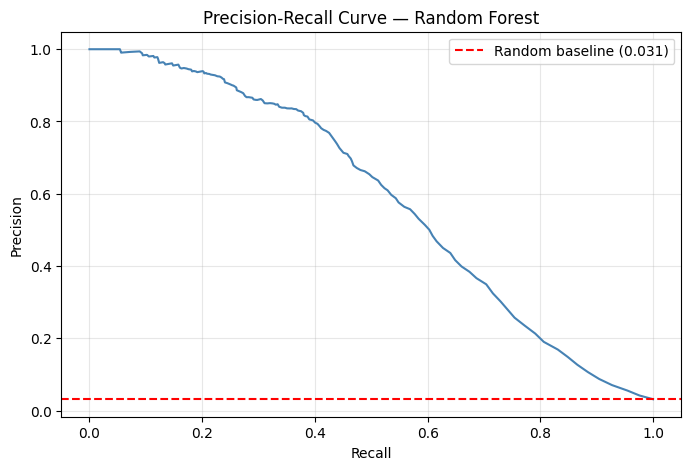

F1-optimal threshold: 0.1850
At F1-optimal — Precision: 0.637 | Recall: 0.512

Threshold    Precision    Recall     Flags
0.100        0.416        0.649      2885
0.150        0.564        0.559      1834
0.200        0.662        0.488      1365
0.250        0.727        0.444      1130
0.300        0.793        0.405      944
0.185        0.637        0.512      1489
0.400        0.849        0.328      715
0.500        0.900        0.253      521


In [22]:
from sklearn.metrics import precision_score, recall_score, precision_recall_curve
import matplotlib.pyplot as plt

y_prob_val_rf = joblib.load('../../models/y_prob_val_rf.pkl')
y_val = joblib.load('../../models/y_val.pkl')

# PR curve
precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob_val_rf)

plt.figure(figsize=(8,5))
plt.plot(recalls, precisions, color='steelblue')
plt.axhline(y=y_val.mean(), color='red', linestyle='--', label=f'Random baseline ({y_val.mean():.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Random Forest')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# F1 optimal threshold
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx   = f1_scores[:-1].argmax()
best_thresh = thresholds[best_idx]

print(f"F1-optimal threshold: {best_thresh:.4f}")
print(f"At F1-optimal — Precision: {precisions[best_idx]:.3f} | Recall: {recalls[best_idx]:.3f}")

# Operating point table
print(f"\n{'Threshold':<12} {'Precision':<12} {'Recall':<10} {'Flags'}")
for t in [0.10, 0.15, 0.20, 0.25, 0.30, best_thresh, 0.40, 0.50]:
    preds = (y_prob_val_rf >= t).astype(int)
    p = precision_score(y_val, preds, zero_division=0)
    r = recall_score(y_val, preds)
    print(f"{t:<12.3f} {p:<12.3f} {r:<10.3f} {preds.sum()}")